# Hedgefundie's Excellent Adventure — can 3x stocks + 3x bonds beat the market forever? 🎢
### The most famous retail leverage recipe, run honestly through 24 years — in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![2022 falsified it?: Mixed](https://img.shields.io/badge/2022_falsified_it%3F-Mixed-8b949e?style=flat-square)

In 2019 an anonymous user called **Hedgefundie** posted a recipe on the Bogleheads forum that became legend: put **55% in UPRO** (a fund that moves 3× the S&P 500 every day) and **45% in TMF** (3× long-term US Treasuries), rebalance every quarter, and hold for decades. The pitch: stocks and bonds usually move in **opposite directions**, so each leg insures the other — letting you run triple leverage without triple ruin. The backtest looked like a money machine.

Then **2022** happened: inflation made stocks *and* bonds crash together, and the strategy lost **64% in one year**. So — was the whole idea a mirage, or did it just take a punch?

> 📓 **Plain-language layer.** Want the *t*-stats, the synthesis validation and the regime tests? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Every chart is drawn by the code beside it** from cached real market data (yfinance; the funds are real from 2009, faithfully reconstructed before — checked against the real funds at 99.8% correlation). House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hfea_leveraged_6040 import data as d, strategy as st

HAVE_REAL = d.have_real()
if HAVE_REAL:
    PX = d.load_real()
    TAPE = d.build_tape(PX, asof=d.AS_OF)
    CAL_S = d.calibrate_fee(TAPE["spy"], TAPE["rf"], TAPE["upro"])
    CAL_B = d.calibrate_fee(TAPE["tlt"], TAPE["rf"], TAPE["tmf"])
    LEGS = d.spliced_legs(TAPE, CAL_S["fee_ann"], CAL_B["fee_ann"])
    HFEA = st.rebalanced(LEGS["s3x"], LEGS["b3x"], st.HFEA_W)["ret"]
    SIXTY = st.rebalanced(LEGS["spy"], LEGS["tlt"], st.SIXTY_FORTY_W)["ret"]
    RF = LEGS["rf"]
else:
    PX = TAPE = LEGS = HFEA = SIXTY = RF = None
print("real HFEA cache present:", HAVE_REAL,
      "| days:", (0 if LEGS is None else len(LEGS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-07-31', 'end': '2026-06-30', 'years': 23.9, 'n_months': 288, 'asof': '2026-06-30', 'fingerprint': 'b276ef14f488', 'cal': [('UPRO (3x SPY)', 2.13, 0.9983, 3.01, 1.0002), ('TMF (3x TLT)', 2.19, 0.9967, 3.64, 0.9998)], 'n_synth_days': 1739, 'n_real_days': 4278, 'n_resets': 96, 'reset_turnover_pct': 13.5, 'perf': [('HFEA 55/45', 17.47, 29.6, -70.8, 0.64, 46.8), ('SPY', 11.24, 18.8, -55.2, 0.68, 12.7), ('60/40 SPY/TLT', 8.99, 10.7, -30.1, 0.75, 7.8), ('UPRO leg (3x SPY)', 16.98, 56.4, -95.6, 0.55, None), ('TMF leg (3x TLT)', -0.39, 42.6, -92.7, 0.15, None)], 'race_spy': (5.42, 1.31), 'race_6040': (7.45, 1.91), 'reg_pre': ('2002-08..2021-12', 11.22, 2.98), 'reg_post': ('2022-01..2026-06', -19.71, -1.59), 'welch_regime': 2.23, 'reg_pre_6040': (11.97, 3.39), 'pre_cagr': (24.28, 0.92, 11.03, 0.72), 'post_cagr': (-8.02, -0.09, 12.18, 0.55), 'y2022': [('UPRO leg', -56.8), ('TMF leg', -72.6), ('HFEA 55/45', -64.2), ('SPY', -18.2), ('60/40', -23.5), ('TLT (1x)', -31.2)], 'corr': {'pre': -0.3, 'y2022': 0.51, 'recent': 0.32, 'full': -0.1}, 'dd': {'peak': '2021-12-27', 'trough': '2023-10-27', 'depth': -70.8, 'now': -32.2}, 'y2008': (-27.0, -36.8), 'y2020': (66.5, 18.3), 'costs': [(2.0, 17.46, 5.41, 1.31, 1.1), (5.0, 17.44, 5.4, 1.3, 2.7), (10.0, 17.41, 5.37, 1.3, 5.4)], 'fee3': (17.19, 5.18, 1.25), 'real_only': (23.07, 0.81, 15.16, 0.96, 6.61, 1.25), 'syn': [('PLANTED', -0.6, 6, 10.36, 4.9, 0.88, 100), ('NULL', 0.6, 0, -3.09, -0.83, 1.03, 0)]}


real HFEA cache present: True | days: 6017


## The answer first

| Question | Answer |
|---|---|
| Did HFEA compound faster than the S&P 500? | **In raw dollars, yes — hugely.** $1 in 2002 became **$46.8** vs **$12.7** in SPY, *even counting* the 2022 disaster. But statistically the edge is too noisy to certify (the strategy swings ~30% a year), and **all** of it came from one regime. |
| Was the "bonds insure stocks" engine real? | **Yes — until it wasn't.** From 2002–2021 stocks and bonds moved oppositely and HFEA beat SPY by **+11%/yr** (statistically solid). In 2022 the relationship **flipped** and both legs crashed together. |
| Is it a better deal than just SPY, per unit of risk? | **No.** Its Sharpe ratio (return per unit of risk) is **0.64 vs SPY's 0.68** — you took triple the rollercoaster for *less* reward per unit of fear. |
| Did 2022 kill the thesis? | **It killed the "law", not the arithmetic.** The recipe still out-compounded SPY over the full 24 years — but 2022 proved the insurance leg only works in the *right regime*, and it's been the wrong regime since. |

> HFEA is a **regime bet with a leverage amplifier** — spectacular when stock-bond correlation is negative, catastrophic when it flips. It is not a money machine.

## 1 · The claim

> *"A 55/45 mix of 3x stocks and 3x long bonds, rebalanced quarterly, compounds faster than the S&P 500 — because the two legs are negatively correlated, the bond leg insures the stock leg, and rebalancing systematically buys whichever just crashed."*

That's **leveraged diversification** — the retail version of what risk-parity hedge funds do (the academic case is real: Asness, Frazzini & Pedersen 2012). Our sibling studies [61](../../61-slow-burn/README.md) and [100](../../100-melting-ice/README.md) tested whether a *single* 3x fund decays to nothing (it doesn't — but it's ruinous alone). This study asks the next question: does the **pair** — the *allocation* — actually work?

## 2 · So what?

Tens of thousands of retail investors run some version of this today. If the claim is true, a patient investor triples the market's compounding with survivable dips. If it's false, they're holding a leveraged time bomb whose fuse is a single macro variable — the stock-bond correlation — that nobody controls. 2022 was the live test: bonds were supposed to be the airbag, and the airbag exploded *with* the car.

## 3 · How would we even know?

- **Real funds, extended honestly.** UPRO and TMF exist since mid-2009. Before that we reconstruct each leg with the exact daily-leverage arithmetic (3× the index, minus borrow costs and fees), **calibrated and checked against the real funds** — 99.8% daily correlation. Full tape: **2002-07-31 → 2026-06-30** (24 years).
- **The recipe, verbatim.** 55/45, reset at every quarter-end close (earning from the next day — no time travel), trading costs charged on every reset.
- **Fair races.** HFEA vs SPY and vs a classic unlevered 60/40, on total returns, with the statistical bar the desk applies to everything: a *t* ≥ 2 on the real tape.
- **The autopsy.** Then we put 2022 on the table and ask what actually failed.

## 4 · The teardown — let's actually look

**The mountain and the cliff.** Here's $1 invested in August 2002, on a log scale (every gridline is 10×).

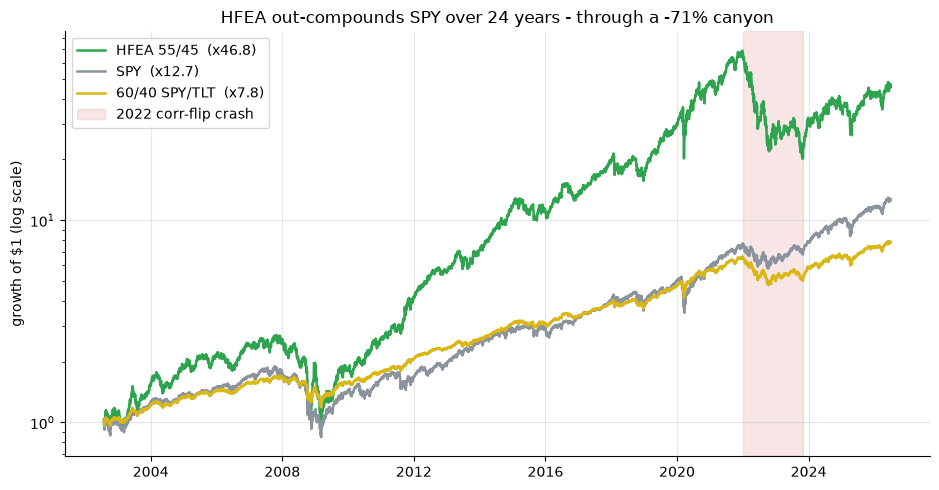

{'HFEA 55/45': 46.8, 'SPY': 12.7, '60/40 SPY/TLT': 7.8}


In [2]:
if HAVE_REAL:
    navs = {'HFEA 55/45': (1+HFEA).cumprod(), 'SPY': (1+LEGS['spy']).cumprod(),
            '60/40 SPY/TLT': (1+SIXTY).cumprod()}
    fig, ax = plt.subplots()
    for (nm, nav), c in zip(navs.items(), [GREEN, GREY, AMBER]):
        ax.plot(nav.index, nav.values, color=c, lw=1.8, label=f'{nm}  (x{nav.iloc[-1]:.1f})')
    ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-10-27'), color=RED, alpha=.12,
               label='2022 corr-flip crash')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log scale)'); ax.legend(loc='upper left')
    ax.set_title('HFEA out-compounds SPY over 24 years - through a -71% canyon')
    plt.tight_layout(); plt.show()
    print({nm: round(float(nav.iloc[-1]),1) for nm, nav in navs.items()})
else:
    print('cache missing - canonical multiples:', {p[0]: p[5] for p in R['perf'][:3]})

$1 became **$46.8** in HFEA vs **$12.7** in SPY and **$7.8** in 60/40 — *including* the 2022 wreck (red band). And here's the quiet magic: the 55/45 **pair** (+17.5%/yr) out-compounded **both of its own ingredients** (3x stocks alone: +17.0%/yr; 3x bonds alone: -0.4%/yr). That's the diversification-plus-rebalancing engine genuinely working — when the correlation cooperates.

**But now the price tag.** Same strategy, drawn as *distance below its own record high*:

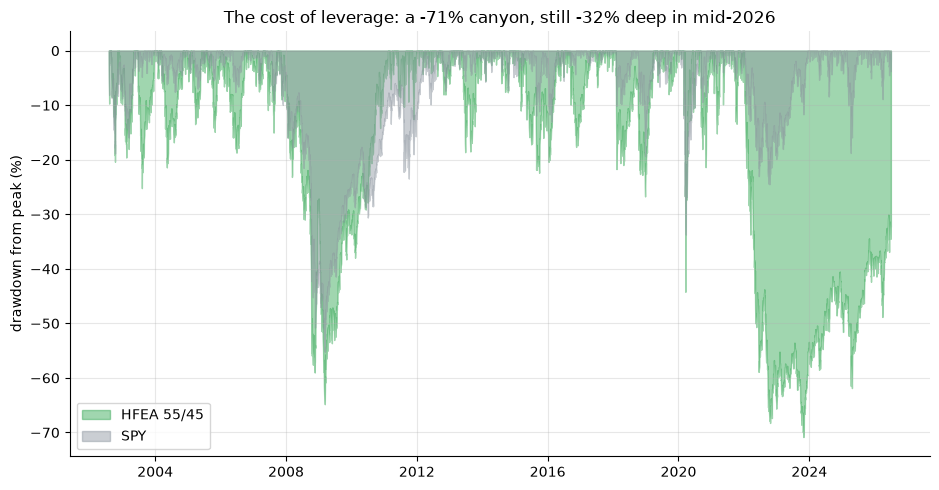

{'peak': '2021-12-27', 'trough': '2023-10-27', 'depth_pct': -70.8386570377137, 'now_vs_peak_pct': -32.23973273862592}


In [3]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    for r, nm, c in [(HFEA, 'HFEA 55/45', GREEN), (LEGS['spy'], 'SPY', GREY)]:
        nav = (1+r).cumprod(); dd = nav/nav.cummax() - 1
        ax.fill_between(dd.index, dd.values*100, 0, color=c, alpha=.45, label=nm)
    ax.set_ylabel('drawdown from peak (%)'); ax.legend(loc='lower left')
    ax.set_title('The cost of leverage: a -71% canyon, still -32% deep in mid-2026')
    plt.tight_layout(); plt.show()
    dd_state = st.drawdown_state(HFEA)
    print(dd_state)
else:
    print('canonical:', R['dd'])

HFEA peaked on **2021-12-27**, fell **-71%** to its **2023-10-27** trough, and in June 2026 — four and a half years later — still sits **-32%** below that peak while SPY makes new highs. Per unit of risk, HFEA was *never* a better deal: Sharpe **0.64** vs SPY's **0.68** vs 60/40's **0.75**.

**What actually broke in 2022?** The insurance. Stocks and bonds had moved in opposite directions for twenty years; in 2022 inflation flipped the relationship and both 3x legs crashed *together*:

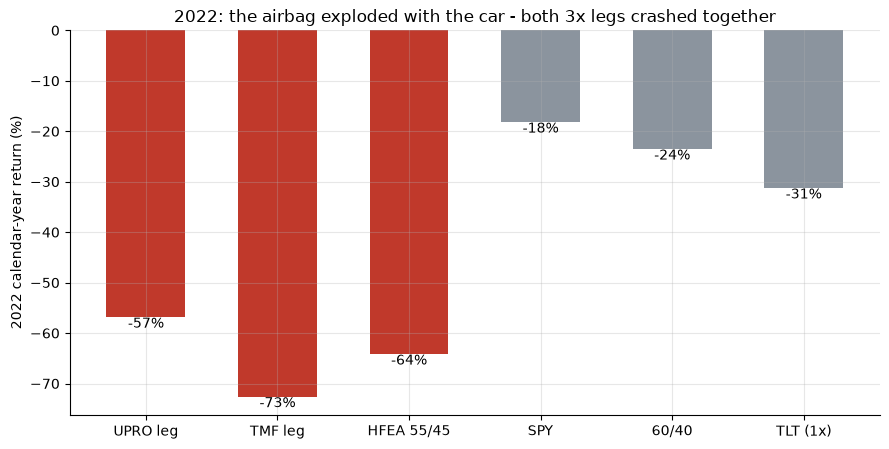

{'UPRO leg': -56.8, 'TMF leg': -72.6, 'HFEA 55/45': -64.2, 'SPY': -18.2, '60/40': -23.5, 'TLT (1x)': -31.2}


In [4]:
if HAVE_REAL:
    names = [n for n,_ in R['y2022']]
    vals = [st.year_return(r, 2022) for r in (LEGS['s3x'], LEGS['b3x'], HFEA,
                                              LEGS['spy'], SIXTY, LEGS['tlt'])]
else:
    names = [n for n,_ in R['y2022']]; vals = [v for _,v in R['y2022']]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
cols = [RED, RED, RED, GREY, GREY, GREY]
ax.bar(names, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}%', (i,v), ha='center',
    va='top' if v<0 else 'bottom')
ax.set_ylabel('2022 calendar-year return (%)')
ax.set_title('2022: the airbag exploded with the car - both 3x legs crashed together')
plt.tight_layout(); plt.show()
print(dict(zip(names, [round(v,1) for v in vals])))

The bond leg — the *insurance* — lost **-73%**, more than the stock leg (-57%). The pair lost **-64%** in a year when plain SPY lost -18%. The stock-bond correlation, **-0.30** over 2002–2021, jumped to **+0.51** in 2022 — and it's still positive (+0.32 in 2024–26). Compare the years the recipe was built on: in **2008** HFEA lost only -27% while SPY lost -37% (3x bonds *doubled* that year), and in **2020** HFEA made **+66%**. When the correlation is negative, the machine is glorious. When it flips, the machine is a trap.

## 5 · The verdict

- **Signal — Mixed.** Over the full 24 years HFEA out-compounded SPY by ~5%/yr in raw CAGR — but the ride is so violent that statistics can't certify the gap (t ≈ 1.3, below the desk's bar of 2). Split by the mechanism itself: **before 2022** the edge was +11%/yr and statistically real (t ≈ 3); **since the correlation flip** it's -20%/yr. Real in one regime, reversed in the other.
- **Tradability — Fragile.** The ETFs are liquid and quarterly rebalancing costs almost nothing — but you're signing up for −71% drawdowns, half-decades under water, *worse* risk-adjusted returns than plain SPY, and a thesis that lives or dies on a macro variable that flipped against it in 2022 and hasn't flipped back.
- **Did 2022 falsify it? — Mixed.** It falsified the *"bonds always insure stocks"* law and the risk-adjusted case. It did **not** erase the raw compounding arithmetic — even including the disaster, $1 → $46.8 vs SPY's $12.7. HFEA works *when and only when* its regime holds.

## 6 · Going further 🚪

- **The single-fund story** — is a 3x ETF alone doomed by "volatility decay"? Siblings [61 — slow-burn](../../61-slow-burn/README.md) and [100 — melting-ice](../../100-melting-ice/README.md) measure that race exactly (spoiler: decay is real maths but path-dependent, and the true killer is the drawdown).
- **The correlation regime itself** — when and why does the stock-bond sign flip? [579 — equity-bond-corr-flip](../../579-equity-bond-corr-flip/README.md) tests it head-on: it's an inflation-regime variable, not a constant of nature.
- **Try to break it.** Re-run with monthly or annual rebalancing (we did — quarterly wasn't cherry-picked), a pessimistic borrow fee on the pre-2009 reconstruction, or the real-funds-only window. The verdict doesn't move.

*Think the next decade brings back negative correlation and cheap money? That's the actual bet HFEA makes — say it out loud before you size it.*